In [466]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import torch
import pandas as pd
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from tqdm.auto import tqdm


In [467]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

SEED = 122
SEEDS = np.random.randint(1000,10000,50)
TEST_YEARS = 5
HORIZON = 1 # Weeks; e.g. =1 use all data points, =52 (smooth for one year)

set_seed(SEED)


In [468]:
df = pd.read_excel(r"C:\Programming\ETH\SS26\ISQT26\final\playground\market_data.xlsx", sheet_name='US', engine='openpyxl', index_col=0)
namings = pd.read_excel(r"C:\Programming\ETH\SS26\ISQT26\final\playground\market_data.xlsx", sheet_name='legend', engine='openpyxl', index_col=0)


In [469]:
df.head()


,EMP,PE,CAPE,DY,Rho,MOV,IR,RR,Y02,Y10,...,YSS,NYF,_AU,_DXY,_LCP,_TY,_OIL,_MKT,_VA,_GR
Date,,,,,,,,,,,,,,,,,,,,,
1988-04-10,0.019766,12.9,14.469,3.60,-0.083,118.0,6.02,-1.061,7.459,8.484,...,0.251622,6.896895,450.50,89.14,2473.7,97.990,16.87,419.06,823.219,462.551
1988-04-17,0.019766,12.4,13.960,3.75,-0.078,121.0,5.88,-0.760,7.582,8.737,...,0.328976,2.631749,456.25,88.31,2328.2,96.534,18.32,404.66,823.219,462.551
1988-04-24,0.019766,12.4,13.950,3.75,-0.051,123.0,5.83,-0.760,7.618,8.773,...,0.156475,2.631749,449.25,88.89,2201.4,96.470,18.13,404.71,823.219,462.551
1988-05-01,0.019602,12.5,14.036,3.75,-0.054,124.2,5.98,-0.760,7.728,8.873,...,0.146747,2.631749,449.00,89.16,2147.8,96.005,18.10,407.55,840.891,461.176
1988-05-08,0.019785,12.3,13.761,3.82,-0.079,118.4,6.29,-0.760,7.885,8.990,...,0.147628,2.631749,443.00,89.30,2200.9,95.446,17.63,401.29,840.891,461.176


In [470]:
namings.head(100)

,Description,Processing,Datastream
Acronym,,,
EMP,number of employees,YoY,TOTMKUS(DWEN)
PE,price/earnings,NaN,TOTMKUS(PE)
CAPE,cyclically adjusted price/earnings,NaN,(TOTMKUS(PI)/CSR#(USCONPRCF))/MAV#(TOTMKUS(PI)...
DY,dividend yield,NaN,TOTMKUS(DY)
Rho,equity/bond correlation,NaN,"CORR#(PCH#(BMUS10Y(CI),5D),PCH#(MSUSAML(MSPI),..."
MOV,implied bond vol,NaN,MOVEIDX
IR,nominal interest rate,NaN,TRUS3MT
RR,real interest rate,NaN,"TRUS3MT-GRFL#(USCCOR..E,10Y)"
Y02,2Y treasury yield,NaN,BMUS02Y(RY)


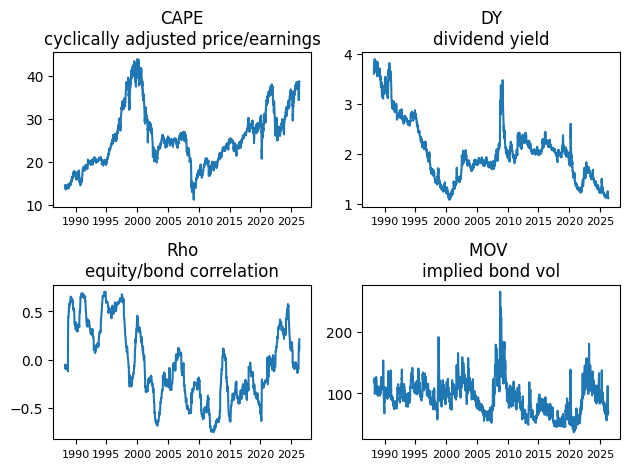

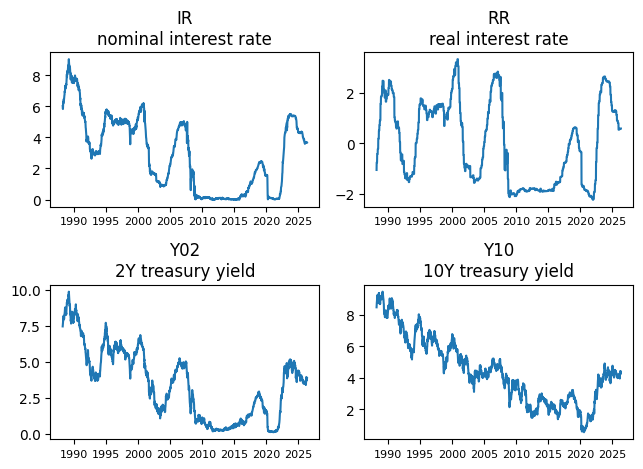

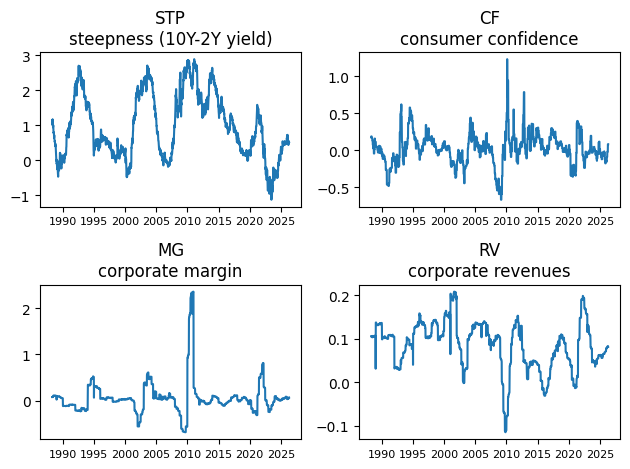

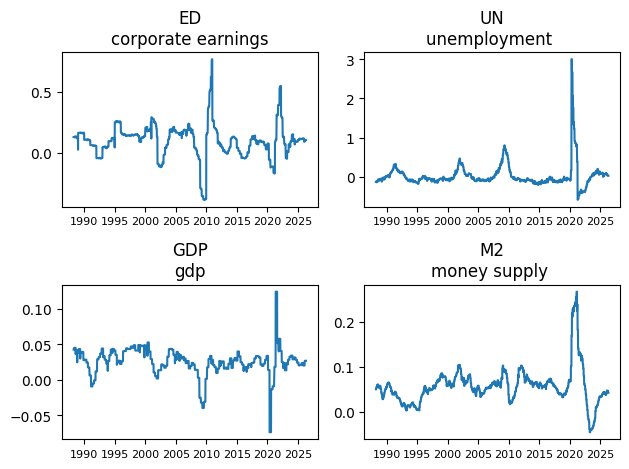

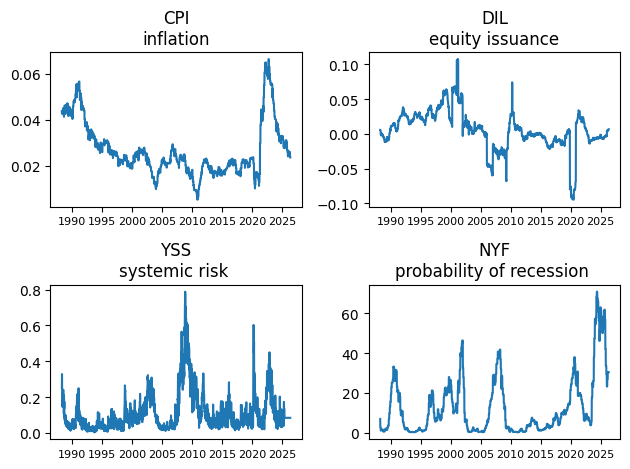

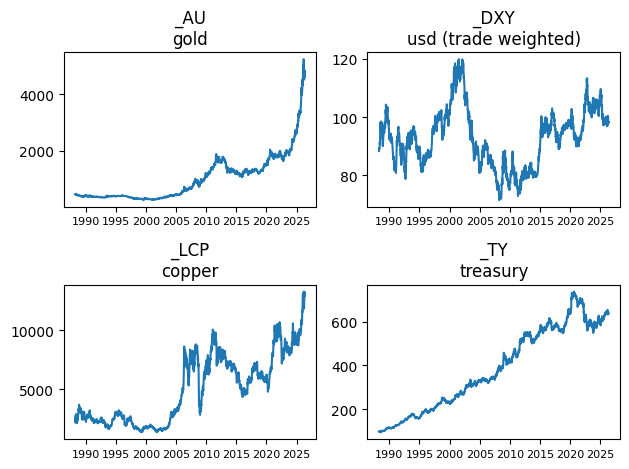

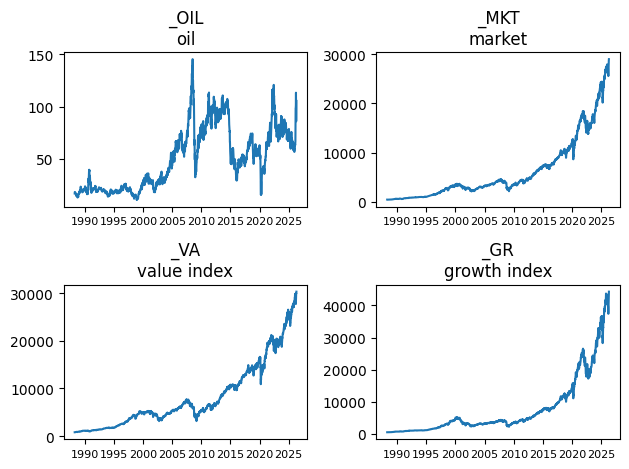

In [471]:
date = df.keys()[0]
j = 0
for i in range(1, len(df.columns) - 1):
    key = df.columns[i + 1]

    plt.subplot(2, 2, j + 1)
    plt.plot((df[key]))
    
    plt.title(f"{key}\n{namings.loc[key, 'Description']}")
    plt.xticks(fontsize=8)


    if j == 3:
        plt.tight_layout()
        plt.show()

        j = 0
    else:
        j += 1

    

In [511]:
def transform_data(X, Y, params=None, horizon=1):

    def safe_log(s):
        return np.log(s.where(s > 0))

    def dlog(s):
        return np.log(s / s.shift(horizon))

    def future_dlog(s):
        return np.log(s.shift(-horizon) / s)

    def fisher(s):
        rho = s.clip(-1 + 1e-6, 1 - 1e-6)
        return np.arctanh(rho)

    def logit_prob(s):
        p = (s / 100).clip(1e-6, 1 - 1e-6)
        return np.log(p / (1 - p))

    Z = pd.DataFrame(index=X.index)

    Z["EMP"]  = X["EMP"]
    Z["PE"]   = safe_log(X["PE"])
    Z["CAPE"] = safe_log(X["CAPE"])
    Z["DY"]   = safe_log(X["DY"])
    Z["Rho"]  = fisher(X["Rho"])
    Z["MOV "] = safe_log(X["MOV "])

    Z["IR"]   = X["IR"]
    Z["RR"]   = X["RR"]
    Z["Y02"]  = X["Y02"]
    Z["Y10"]  = X["Y10"]
    Z["STP"]  = X["STP"]

    Z["CF"]   = X["CF"]
    Z["MG"]   = X["MG"]
    Z["RV"]   = X["RV"]
    Z["ED"]   = X["ED"]
    Z["UN"]   = X["UN"]
    Z["GDP"]  = X["GDP"]
    Z["M2"]   = X["M2"]
    Z["CPI"]  = X["CPI"]
    Z["DIL"]  = X["DIL"]

    Z["YSS"]  = np.log1p(X["YSS"])
    Z["NYF"]  = logit_prob(X["NYF"])

    Z["_AU"]  = dlog(X["_AU"])
    Z["_DXY"] = dlog(X["_DXY"])
    Z["_LCP"] = dlog(X["_LCP"])
    Z["_TY"]  = dlog(X["_TY"])
    Z["_OIL"] = dlog(X["_OIL"])

    Z["_VA"]  = dlog(X["_VA"])
    Z["_GR"]  = dlog(X["_GR"])

    y = future_dlog(Y)
    y.name = "_MKT"

    data = pd.concat([Z, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    Z = data.drop(columns=["_MKT"])
    y = data["_MKT"]

    if params is None:
        params = {
            "X_mean": Z.mean(),
            "X_std": Z.std(ddof=0).replace(0, 1),
            "Y_mean": y.mean(),
            "Y_std": y.std(ddof=0),
        }

    Z = (Z - params["X_mean"]) / params["X_std"]
    y = (y - params["Y_mean"]) / params["Y_std"]

    return Z, y, params


def split_transform_data(df, target="_MKT", test_years=5, horizon=1):
    split_date = df.index.max() - pd.DateOffset(years=test_years)

    train = df.loc[df.index < split_date]
    test = df.loc[df.index >= split_date]

    X_train_raw = train.drop(columns=[target])
    Y_train_raw = train[target]

    X_test_raw = test.drop(columns=[target])
    Y_test_raw = test[target]

    X_train, Y_train, params = transform_data(
        X_train_raw,
        Y_train_raw,
        horizon=horizon
    )

    X_test, Y_test, _ = transform_data(
        X_test_raw,
        Y_test_raw,
        params=params,
        horizon=horizon
    )

    return X_train, X_test, Y_train, Y_test, params, split_date

In [512]:
df = df.copy()

X_train, X_test, Y_train, Y_test, params, split_date = split_transform_data(
    df,
    target="_MKT",
    test_years=TEST_YEARS,
    horizon=HORIZON
)


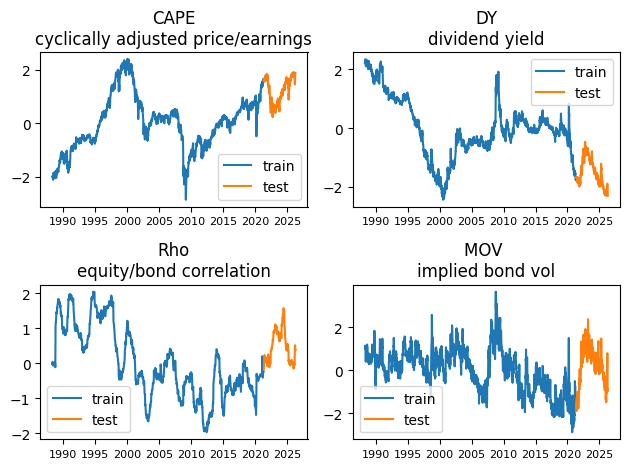

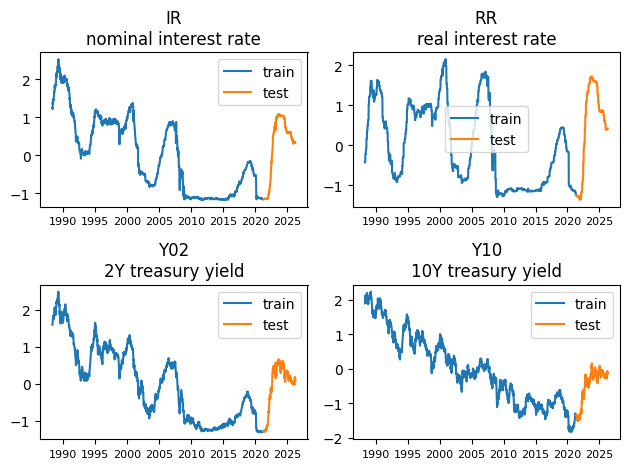

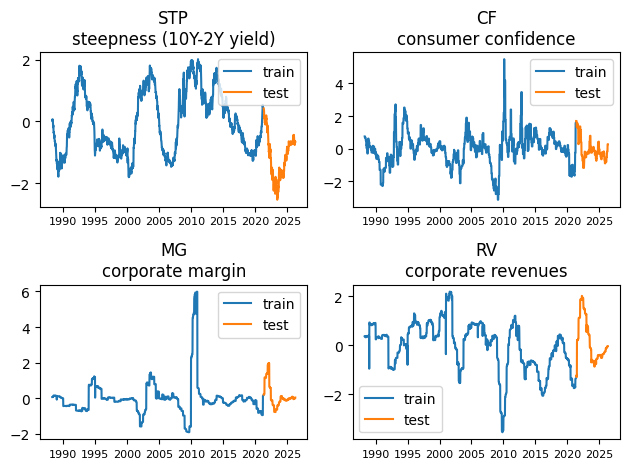

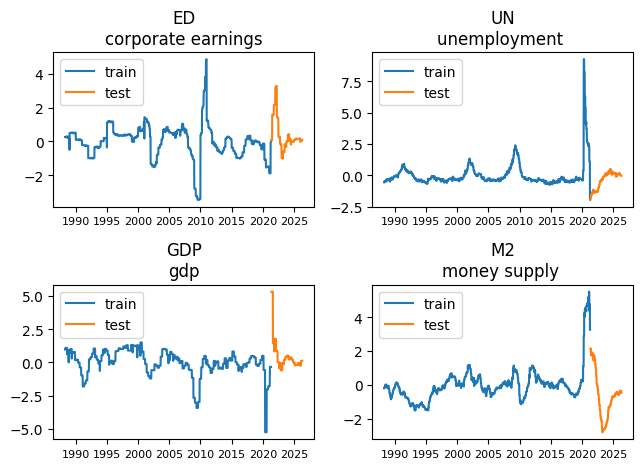

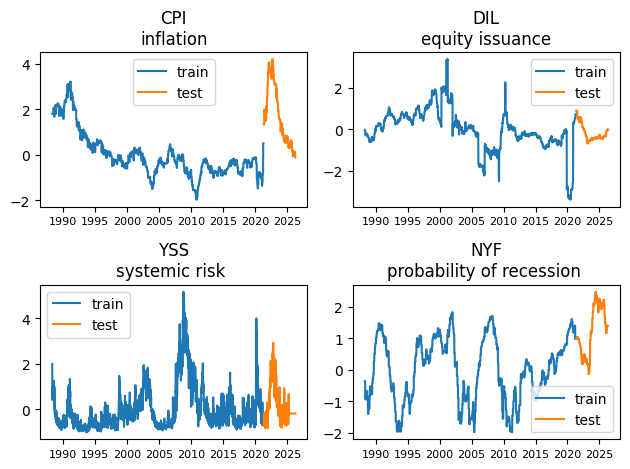

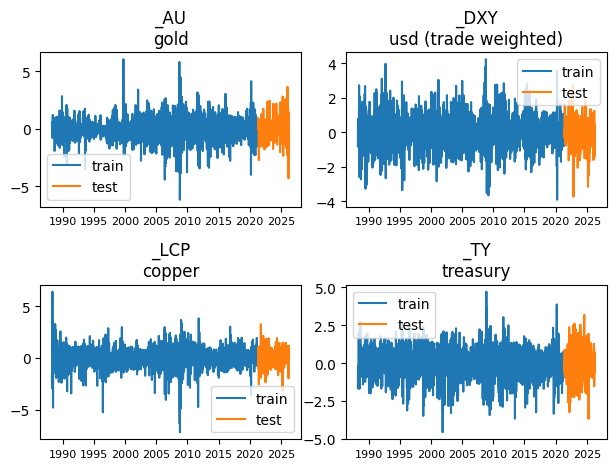

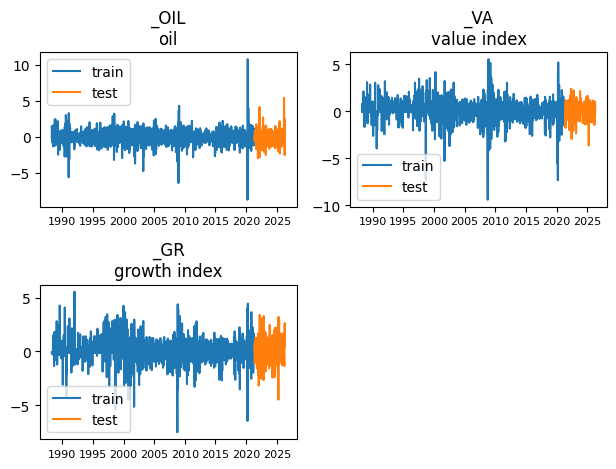

In [513]:
date = X_train.keys()[0]
j = 0
for i in range(1, len(X_train.columns) - 1):
    key = X_train.columns[i + 1]

    plt.subplot(2, 2, j + 1)
    plt.plot((X_train[key]),label="train")
    plt.plot((X_test[key]),label="test")
    plt.legend()
    plt.title(f"{key}\n{namings.loc[key, 'Description']}")
    plt.xticks(fontsize=8)


    if j == 3 or i == (len(X_train.columns) - 2):
        plt.tight_layout()
        plt.show()

        j = 0
    else:
        j += 1

    

In [514]:
def lagged_corr_matrix(X, Y, max_lag=5):
    X = X.copy()
    Y = Y.copy()

    common_idx = X.index.intersection(Y.index)
    X = X.loc[common_idx]
    Y = Y.loc[common_idx]

    lags = range(-max_lag, max_lag + 1)
    corr = pd.DataFrame(index=X.columns, columns=lags, dtype=float)

    for lag in lags:
        X_lagged = X.shift(lag)
        for col in X.columns:
            tmp = pd.concat([X_lagged[col], Y], axis=1).dropna()
            corr.loc[col, lag] = tmp.iloc[:, 0].corr(tmp.iloc[:, 1])

    return corr


In [515]:
def plot_lagged_corr(X, Y, max_lag=5, figsize=None, annot=True, fontsize=16):
    corr = lagged_corr_matrix(X, Y, max_lag=max_lag)

    if figsize is None:
        figsize = (1.0 * (2 * max_lag + 1), 0.60 * len(corr) + 3)

    fig, ax = plt.subplots(figsize=figsize)

    cmap = LinearSegmentedColormap.from_list(
        "blue_green_red",
        [
            (0.00, "green"),
            (0.50, "lightyellow"),
            (1.00, "red")
        ]
    )

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    im = ax.imshow(
        corr.values,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    ax.set_xticks(np.arange(corr.shape[1]))
    ax.set_xticklabels(corr.columns, fontsize=fontsize)

    ax.set_yticks(np.arange(corr.shape[0]))
    ax.set_yticklabels(corr.index, fontsize=fontsize)

    ax.set_xlabel(f"Lag k: Corr($X_{{t+k}}, Y_{{t}}$)", fontsize=fontsize)
    ax.set_ylabel("Feature", fontsize=fontsize)
    ax.set_title(
        f"Lagged correlation of $X_{{train}}$ with $Y_{{train}}$, $\pm${max_lag} weeks",
        fontsize=fontsize
    )

    ax.tick_params(axis="both", labelsize=fontsize)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Correlation", fontsize=fontsize)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.ax.tick_params(labelsize=fontsize)

    plt.tight_layout()
    plt.show()

    return corr

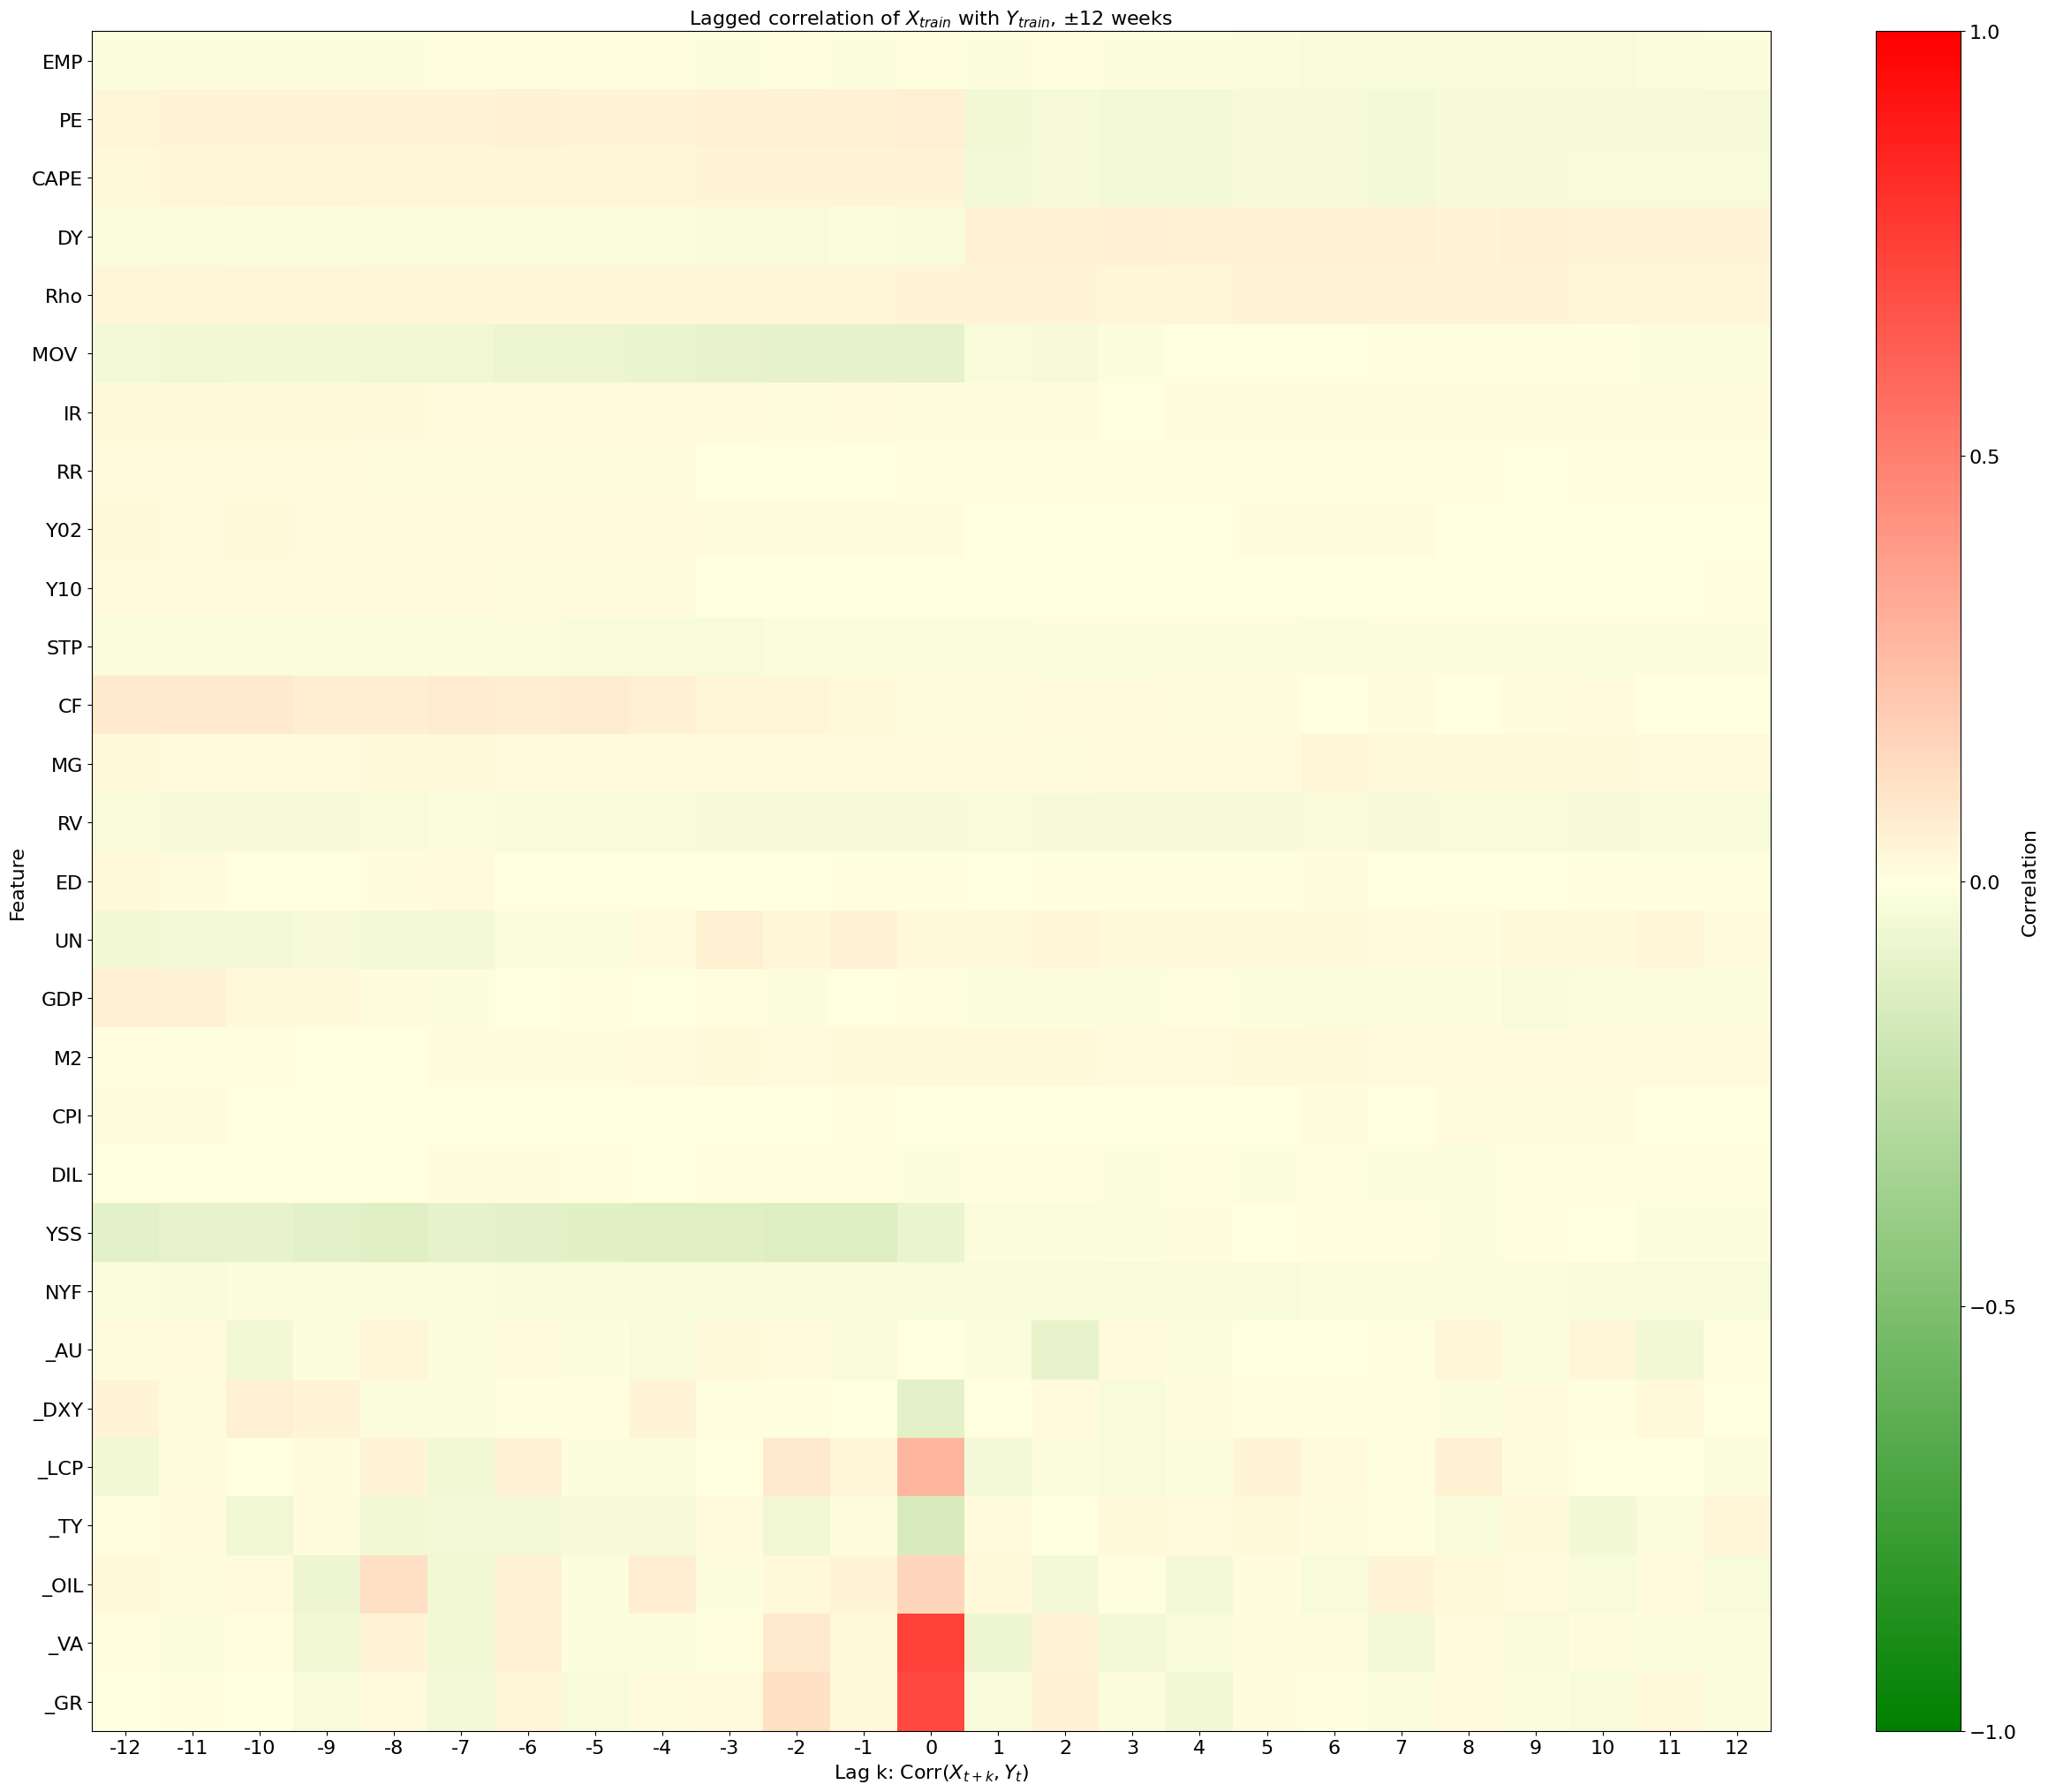

In [477]:
corr_train = plot_lagged_corr(X_train, Y_train, max_lag=12,fontsize=16)

In [516]:
class RNNModel(torch.nn.Module):
    def __init__(self, n_features, hidden_size, seed=0):
        super().__init__()
        set_seed(seed)

        self.rnn = torch.nn.RNN(
            input_size=n_features,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.out = torch.nn.Linear(hidden_size, 1)

    def forward(self, X):
        h, _ = self.rnn(X)
        y = self.out(h[:, -1, :])
        return y

In [518]:
Y_train = Y_train.copy()
Y_train.name = "_MKT"
Y_test = Y_test.copy()
Y_test.name = "_MKT"

train_data = pd.concat([X_train, Y_train], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
test_data = pd.concat([X_test, Y_test], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

X_train = train_data.drop(columns=["_MKT"])
Y_train = train_data["_MKT"]
X_test = test_data.drop(columns=["_MKT"])
Y_test = test_data["_MKT"]

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)


In [519]:
print(X_train_tensor.shape,X_test_tensor.shape)

torch.Size([1724, 29]) torch.Size([259, 29])


In [520]:
def tr(
    X_train, Y_train,
    X_test, Y_test,
    model,
    lr=1e-3,
    weight_decay=0.0,
    epochs=1000,
    seed=None,
    show_progress=True):

    if seed is not None:
        set_seed(seed)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_fn = torch.nn.MSELoss()
    train_losses, test_losses = [], []
    train_hits, test_hits = [], []
    iterator = tqdm(range(epochs), desc="Training") if show_progress else range(epochs)

    for _ in iterator:
        model.train()
        opt.zero_grad()

        train_pred = model(X_train)
        train_loss = loss_fn(train_pred, Y_train)
        train_loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_loss = loss_fn(test_pred, Y_test)
            train_hit = (torch.sign(train_pred) == torch.sign(Y_train)).float().mean()
            test_hit = (torch.sign(test_pred) == torch.sign(Y_test)).float().mean()

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_hits.append(train_hit.item())
        test_hits.append(test_hit.item())

        if show_progress:
            iterator.set_postfix({
                "train_loss": f"{train_loss.item():.4f}",
                "test_loss": f"{test_loss.item():.4f}",
                "train_hit": f"{train_hit.item():.3f}",
                "test_hit": f"{test_hit.item():.3f}",
            })

    return {
        "model": model,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_hits": train_hits,
        "test_hits": test_hits,
    }


In [550]:
n_features = X_train_tensor.shape[1]
hidden_size = 32

model = RNNModel(n_features, hidden_size)
X_train_rnn = X_train_tensor.unsqueeze(1)
X_test_rnn  = X_test_tensor.unsqueeze(1)


In [551]:
hist = tr(
    X_train_rnn,
    Y_train_tensor,
    X_test_rnn,
    Y_test_tensor,
    model,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=10000
)

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

In [552]:
def get_predictions(model, X_train, Y_train, X_test, Y_test):
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train).detach().numpy().ravel()
        test_pred = model(X_test).detach().numpy().ravel()

    y_train = Y_train.detach().numpy().ravel()
    y_test = Y_test.detach().numpy().ravel()

    return train_pred, y_train, test_pred, y_test


def evaluate_model(model, X_train, Y_train, X_test, Y_test):
    train_pred, y_train, test_pred, y_test = get_predictions(
        model, X_train, Y_train, X_test, Y_test
    )

    residuals = y_test - test_pred
    train_mse = np.mean((y_train - train_pred) ** 2)
    test_mse = np.mean((y_test - test_pred) ** 2)
    train_hit = np.mean(np.sign(train_pred) == np.sign(y_train))
    test_hit = np.mean(np.sign(test_pred) == np.sign(y_test))
    test_corr = np.corrcoef(y_test, test_pred)[0, 1]

    return {
        "train_pred": train_pred,
        "y_train": y_train,
        "test_pred": test_pred,
        "y_test": y_test,
        "residuals": residuals,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_hit": train_hit,
        "test_hit": test_hit,
        "test_corr": test_corr,
    }


def run_seeds(
    seeds,
    X_train,
    Y_train,
    X_test,
    Y_test,
    n_features,
    hidden_size=8,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=1000):

    runs = {}
    rows = []

    for seed in tqdm(seeds, desc="Seeds"):
        model = RNNModel(n_features, hidden_size, seed=seed)
        hist = tr(
            X_train,
            Y_train,
            X_test,
            Y_test,
            model,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
            seed=seed,
            show_progress=False
        )
        diag = evaluate_model(hist["model"], X_train, Y_train, X_test, Y_test)
        runs[seed] = {"hist": hist, "diag": diag}
        rows.append({
            "seed": seed,
            "train_mse": diag["train_mse"],
            "test_mse": diag["test_mse"],
            "train_hit": diag["train_hit"],
            "test_hit": diag["test_hit"],
            "test_corr": diag["test_corr"],
        })

    return runs, pd.DataFrame(rows).set_index("seed")


In [553]:
def plot_training_diagnostics(hist, model, X_train, Y_train, X_test, Y_test):
    train_pred, y_train, test_pred, y_test = get_predictions(
        model, X_train, Y_train, X_test, Y_test
    )


    plt.figure(figsize=(12, 6))
    plt.plot(hist["train_losses"], label="Train loss")
    plt.plot(hist["test_losses"], label="Test loss")
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("MSE loss", fontsize=14)
    plt.title("Training and test loss", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

 
    plt.figure(figsize=(12, 6))
    plt.plot(hist["train_hits"], label="Train hit rate")
    plt.plot(hist["test_hits"], label="Test hit rate")
    plt.axhline(0.5, linestyle="--", label="Random baseline")
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Hit rate", fontsize=14)
    plt.title("Directional hit rate", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(14, 6))
    plt.plot(y_test, label="Actual Y_test")
    plt.plot(test_pred, label="Predicted Y_test")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Test observation", fontsize=14)
    plt.ylabel("Standardized return", fontsize=14)
    plt.title("Test predictions vs actual", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, test_pred, alpha=0.7)
    lo = min(y_test.min(), test_pred.min())
    hi = max(y_test.max(), test_pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("Actual Y_test", fontsize=14)
    plt.ylabel("Predicted Y_test", fontsize=14)
    plt.title("Predicted vs actual", fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    residuals = y_test - test_pred

    plt.figure(figsize=(14, 6))
    plt.plot(residuals, label="Residual")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Test observation", fontsize=14)
    plt.ylabel("Actual - predicted", fontsize=14)
    plt.title("Test residuals", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    train_mse = np.mean((y_train - train_pred) ** 2)
    test_mse  = np.mean((y_test - test_pred) ** 2)

    train_hit = np.mean(np.sign(train_pred) == np.sign(y_train))
    test_hit  = np.mean(np.sign(test_pred) == np.sign(y_test))

    test_corr = np.corrcoef(y_test, test_pred)[0, 1]

    print("Train MSE:", train_mse)
    print("Test MSE :", test_mse)
    print("Train hit:", train_hit)
    print("Test hit :", test_hit)
    print("Test corr:", test_corr)

    return {
        "train_pred": train_pred,
        "y_train": y_train,
        "test_pred": test_pred,
        "y_test": y_test,
        "residuals": residuals,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_hit": train_hit,
        "test_hit": test_hit,
        "test_corr": test_corr,
    }

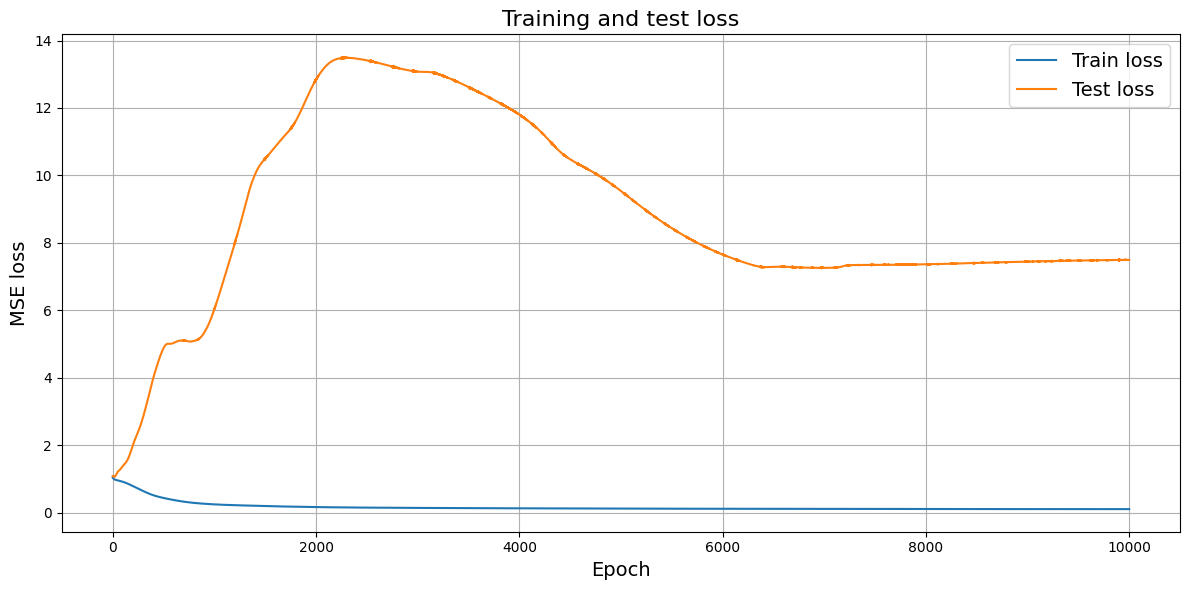

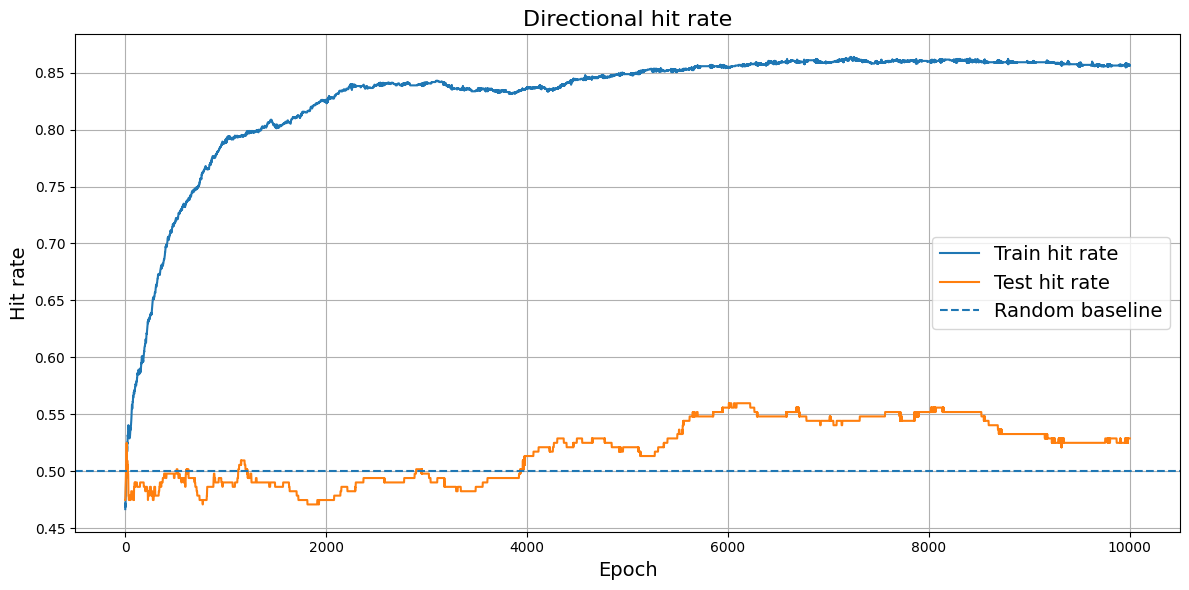

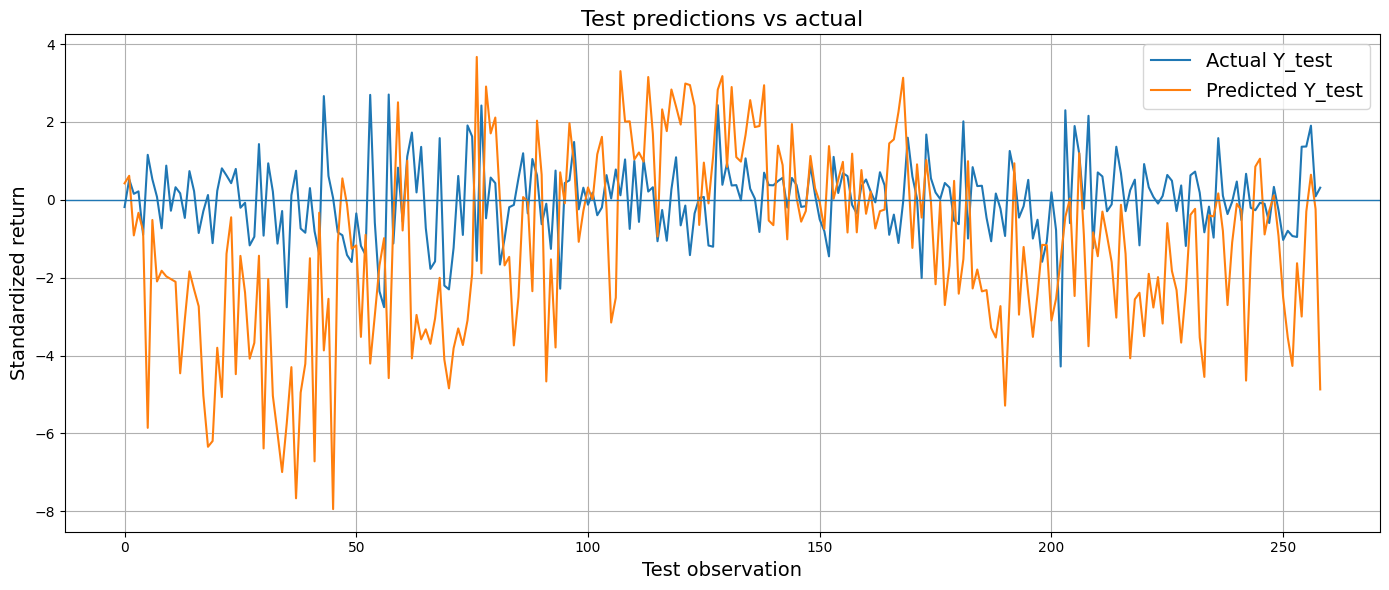

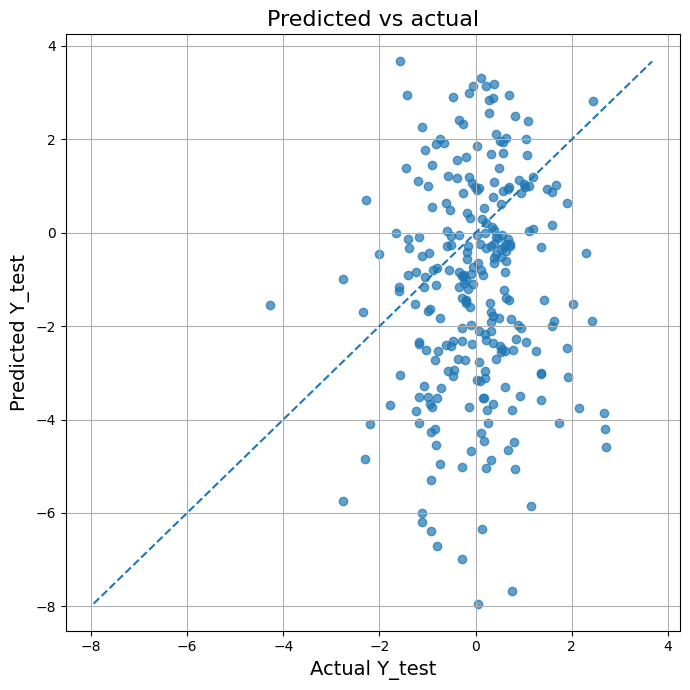

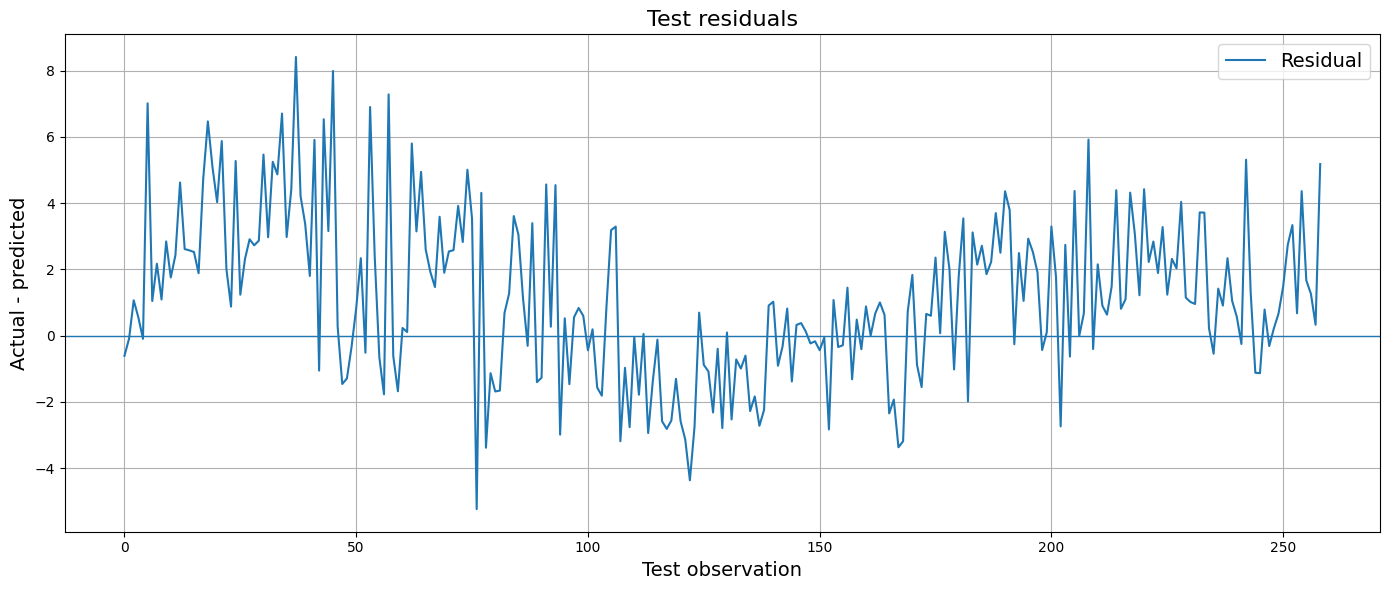

Train MSE: 0.10644343
Test MSE : 7.496602
Train hit: 0.8561484918793504
Test hit : 0.528957528957529
Test corr: 0.06289123076663442


In [554]:
diag = plot_training_diagnostics(
    hist,
    hist["model"],
    X_train_rnn,
    Y_train_tensor,
    X_test_rnn,
    Y_test_tensor
)

In [487]:
seed_runs, seed_summary = run_seeds(
    SEEDS,
    X_train_rnn,
    Y_train_tensor,
    X_test_rnn,
    Y_test_tensor,
    n_features,
    hidden_size=hidden_size,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=1000
)

seed_summary


Seeds:   0%|          | 0/50 [00:00<?, ?it/s]

,train_mse,test_mse,train_hit,test_hit,test_corr
seed,,,,,
8663,0.366669,0.248198,0.807536,0.873077,0.910573
3442,0.386730,0.298776,0.813913,0.811538,0.890952
7974,0.329104,0.265520,0.824928,0.834615,0.880541
2342,0.366763,0.145312,0.829565,0.938462,0.948574
1694,0.362404,0.290017,0.819130,0.853846,0.902706
4498,0.393502,0.335365,0.808696,0.811538,0.908672
2045,0.336101,0.213540,0.835362,0.853846,0.922430
1419,0.391486,0.284430,0.816232,0.823077,0.911450
7884,0.379021,0.096119,0.817391,0.946154,0.960481


In [508]:
seed_summary.describe()

,train_mse,test_mse,train_hit,test_hit,test_corr
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.363543,0.278750,0.823316,0.852462,0.899130
std,0.022241,0.113323,0.008535,0.055343,0.041639
min,0.317552,0.096119,0.807536,0.761538,0.803277
25%,0.348358,0.183057,0.816377,0.811538,0.879546
50%,0.364675,0.273125,0.823188,0.850000,0.906135
75%,0.378903,0.335091,0.830000,0.895192,0.928073
max,0.422377,0.524791,0.841159,0.961538,0.965641


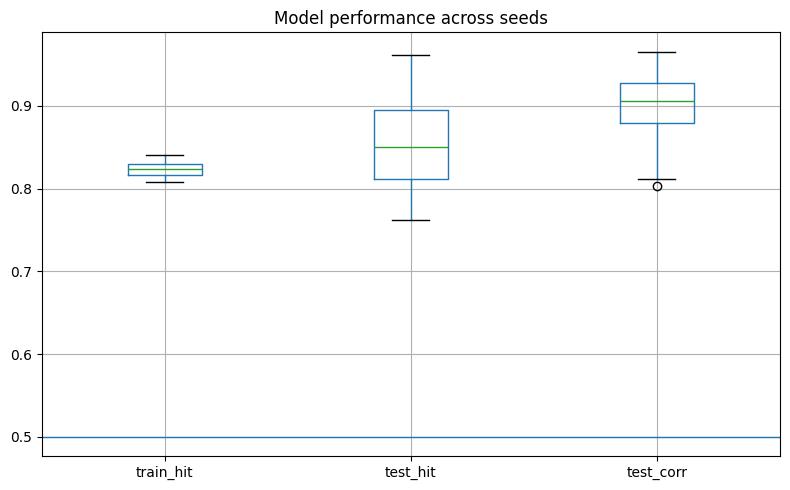

In [509]:
seed_summary[["train_hit", "test_hit", "test_corr"]].boxplot(figsize=(8, 5))
plt.axhline(0.5, linewidth=1)
plt.title("Model performance across seeds")
plt.tight_layout()
plt.show()

In [555]:
check = pd.DataFrame({
    "pred": diag["test_pred"],
    "Y_test": Y_test.values,
    "raw_mkt": df.loc[X_test.index, "_MKT"],
}, index=X_test.index)

check["raw_return_same_week"] = check["raw_mkt"].pct_change()
check["raw_return_next_week"] = check["raw_mkt"].pct_change().shift(-1)

check[["pred", "Y_test", "raw_return_same_week", "raw_return_next_week"]].corr()

,pred,Y_test,raw_return_same_week,raw_return_next_week
pred,1.000000,0.062891,0.153174,0.062786
Y_test,0.062891,1.000000,-0.073697,0.999790
raw_return_same_week,0.153174,-0.073697,1.000000,-0.079992
raw_return_next_week,0.062786,0.999790,-0.079992,1.000000


In [556]:
def make_dynamic_exposure(pred, threshold=1.0, step=0.1, base=1.0, min_w=0.0, max_w=2.0):
    pred = np.asarray(pred).ravel()

    w = np.empty_like(pred, dtype=float)
    current_w = base

    for i, p in enumerate(pred):
        if p > threshold:
            current_w -= step
        elif p < -threshold:
            current_w += step

        current_w = np.clip(current_w, min_w, max_w)
        w[i] = current_w

    return w

In [557]:
def backtest_dynamic_exposure_self_financing(
    pred,
    raw_mkt,
    threshold=1.0,
    step=0.1,
    base=1.0,
    min_w=0.0,
    max_w=2.0
):
    pred = np.asarray(pred).ravel()
    raw_mkt = pd.Series(raw_mkt).dropna().iloc[-len(pred):]

    w = make_dynamic_exposure(
        pred,
        threshold=threshold,
        step=step,
        base=base,
        min_w=min_w,
        max_w=max_w
    )

    bt = pd.DataFrame(index=raw_mkt.index)
    bt["S"] = raw_mkt.values
    bt["pred_next"] = pred
    bt["w"] = w

    bt["dw"] = bt["w"].diff()
    bt["dw"].iloc[0] = bt["w"].iloc[0] - base

    bt["trade_cashflow"] = -bt["dw"] * bt["S"]

    bt["cash"] = bt["trade_cashflow"].cumsum()
    bt["position_value"] = bt["w"] * bt["S"]

    initial_position_value = base * bt["S"].iloc[0]

    bt["strategy_value"] = bt["cash"] + bt["position_value"]
    bt["strategy_pnl"] = bt["strategy_value"] - initial_position_value

    bt["buy_hold_value"] = base * bt["S"]
    bt["buy_hold_pnl"] = bt["buy_hold_value"] - initial_position_value

    bt["active_pnl"] = bt["strategy_pnl"] - bt["buy_hold_pnl"]

    return bt

In [558]:
raw_mkt_test = df.loc[X_test.index, "_MKT"]

bt_test = backtest_dynamic_exposure_self_financing(
    pred=diag["test_pred"],
    raw_mkt=raw_mkt_test,
    threshold=1.5,
    step=0.5,
    base=1.0,
    min_w=0.0,
    max_w=2.0
)

raw_mkt_train = df.loc[X_train.index, "_MKT"]

bt_train = backtest_dynamic_exposure_self_financing(
    pred=diag["train_pred"],
    raw_mkt=raw_mkt_train,
    threshold=1.5,
    step=0.5,
    base=1.0,
    min_w=0.0,
    max_w=2.0
)

C:\Users\trist\AppData\Local\Temp\ipykernel_31620\2153938373.py:28: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  bt["dw"].iloc[0] = bt["w"].iloc[0] - base
C:\Users\trist\AppData\Local\Temp\ipykernel_31620\2153938373.py:28: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves

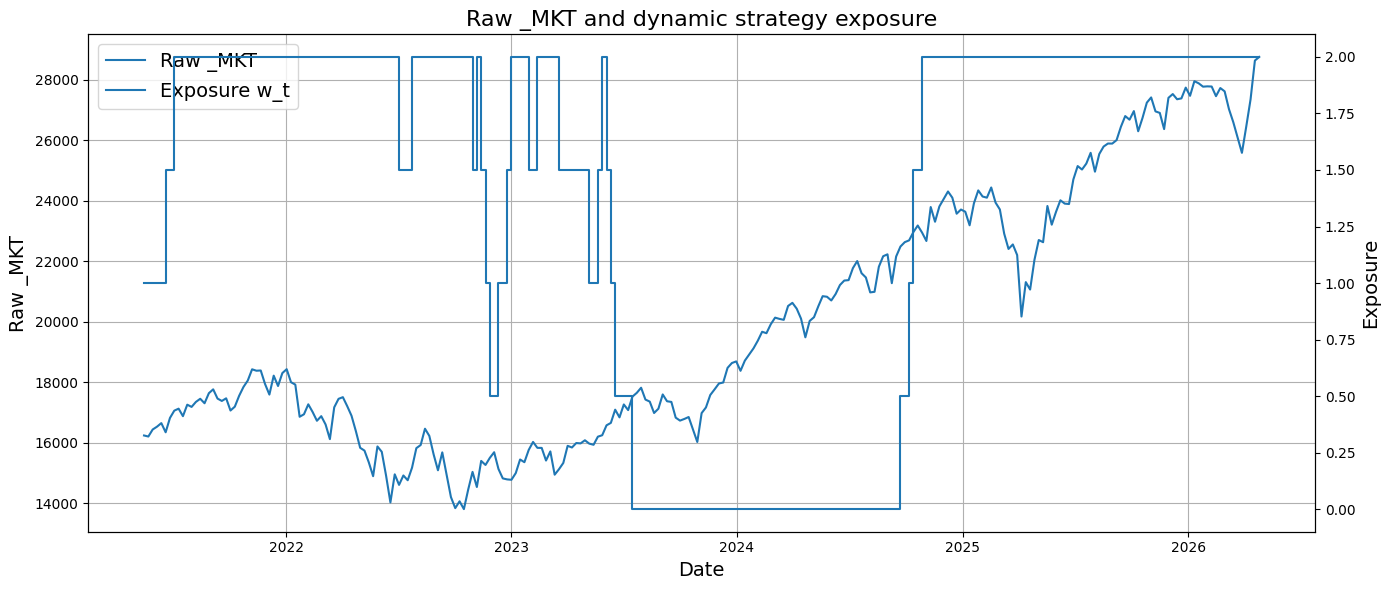

In [559]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_test.index, bt_test["S"], label="Raw _MKT")
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw _MKT", fontsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_test.index, bt_test["w"], where="post", label="Exposure w_t")
ax2.set_ylabel("Exposure", fontsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("Raw _MKT and dynamic strategy exposure", fontsize=16)
plt.tight_layout()
plt.show()

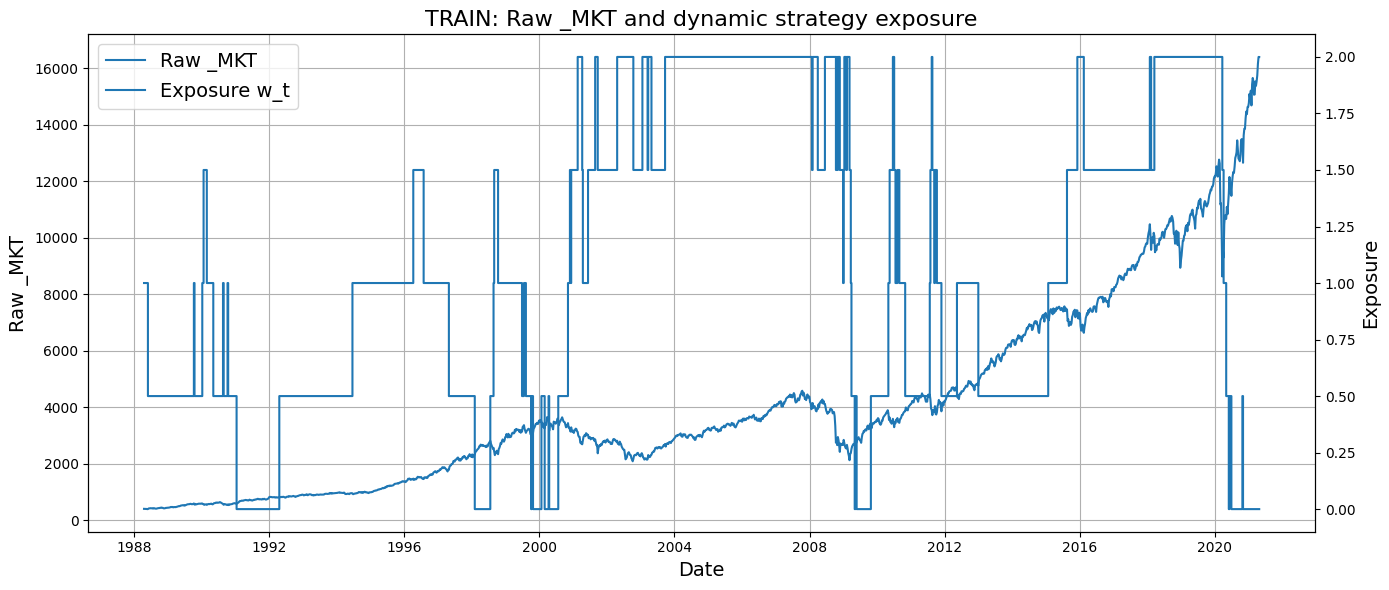

In [560]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_train.index, bt_train["S"], label="Raw _MKT")
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw _MKT", fontsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_train.index, bt_train["w"], where="post", label="Exposure w_t")
ax2.set_ylabel("Exposure", fontsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("TRAIN: Raw _MKT and dynamic strategy exposure", fontsize=16)
plt.tight_layout()
plt.show()

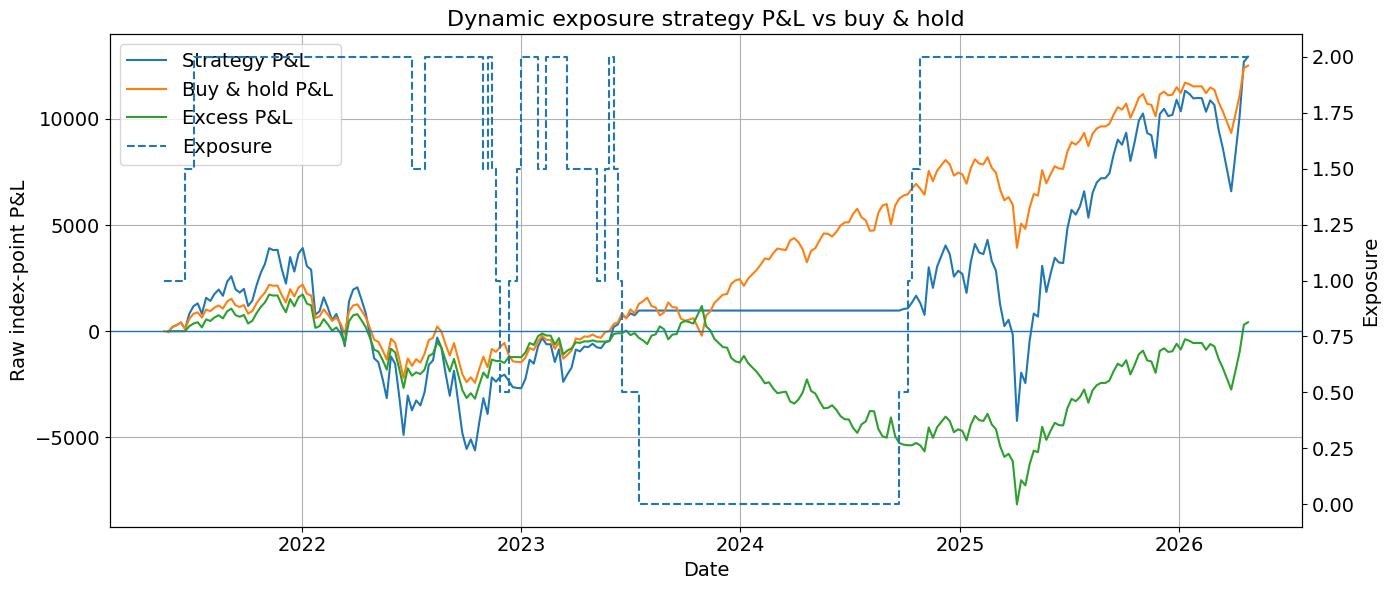

In [561]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_test.index, bt_test["strategy_pnl"], label="Strategy P&L")
ax1.plot(bt_test.index, bt_test["buy_hold_pnl"], label="Buy & hold P&L")
ax1.plot(bt_test.index, bt_test["strategy_pnl"] - bt_test["buy_hold_pnl"], label="Excess P&L")

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw index-point P&L", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_test.index, bt_test["w"], where="post", label="Exposure", linestyle="--")
ax2.set_ylabel("Exposure", fontsize=14)
ax2.tick_params(axis="both", labelsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()

ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("Dynamic exposure strategy P&L vs buy & hold", fontsize=16)
plt.tight_layout()
plt.show()

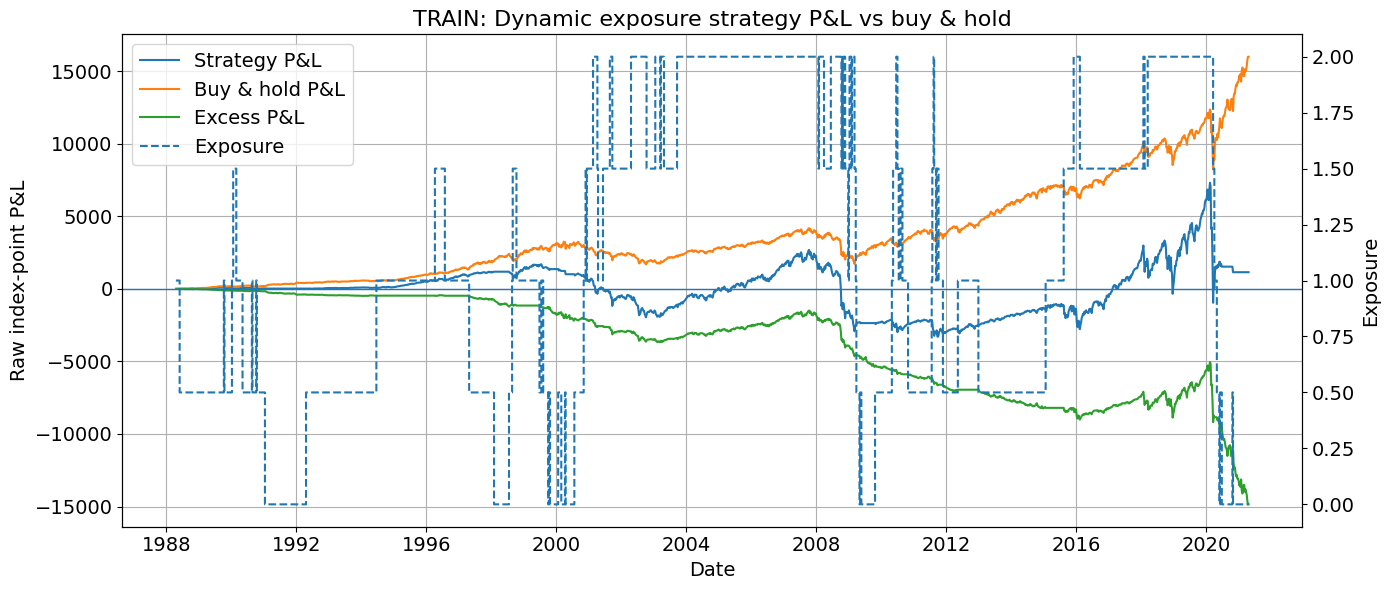

In [562]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_train.index, bt_train["strategy_pnl"], label="Strategy P&L")
ax1.plot(bt_train.index, bt_train["buy_hold_pnl"], label="Buy & hold P&L")
ax1.plot(
    bt_train.index,
    bt_train["strategy_pnl"] - bt_train["buy_hold_pnl"],
    label="Excess P&L"
)

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw index-point P&L", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_train.index, bt_train["w"], where="post", label="Exposure", linestyle="--")
ax2.set_ylabel("Exposure", fontsize=14)
ax2.tick_params(axis="both", labelsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()

ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("TRAIN: Dynamic exposure strategy P&L vs buy & hold", fontsize=16)
plt.tight_layout()
plt.show()

In [563]:
def add_ir_returns(bt):
    bt = bt.copy()

    bt["mkt_ret"] = bt["S"].pct_change()
    bt["strategy_ret"] = bt["w"].shift(1) * bt["mkt_ret"]
    bt["active_ret"] = bt["strategy_ret"] - bt["mkt_ret"]

    bt[["mkt_ret", "strategy_ret", "active_ret"]] = (
        bt[["mkt_ret", "strategy_ret", "active_ret"]]
        .replace([np.inf, -np.inf], np.nan)
    )

    return bt

In [565]:
def IR(bt, periods_per_year=52):
    tmp = bt["active_ret"].dropna()
    if tmp.std(ddof=1) == 0:
        return np.nan
    return tmp.mean() / tmp.std(ddof=1) * np.sqrt(periods_per_year)

In [536]:
bt_train_ir = add_ir_returns(bt_train)
bt_test_ir = add_ir_returns(bt_test)

bt_all_ir = pd.concat([bt_train_ir, bt_test_ir]).sort_index()

In [567]:
ir_summary = pd.Series({
    "train_IR": IR(bt_train_ir),
    "test_IR": IR(bt_test_ir),
    "all_IR": IR(bt_all_ir),
})

ir_summary

train_IR   -0.019724
test_IR     0.744079
all_IR      0.098392
dtype: float64

In [568]:
bt_train_tmp = bt_train_ir.copy()
bt_test_tmp = bt_test_ir.copy()

bt_train_tmp["sample"] = "train"
bt_test_tmp["sample"] = "test"

bt_all_tmp = pd.concat([bt_train_tmp, bt_test_tmp]).sort_index()

yearly_IR = bt_all_tmp.groupby([bt_all_tmp.index.year, "sample"]).apply(IR)
yearly_IR.name = "IR"

yearly_IR

Date  sample
1988  train          NaN
1989  train          NaN
1990  train          NaN
1991  train          NaN
1992  train          NaN
1993  train          NaN
1994  train          NaN
1995  train    -4.730743
1996  train    -1.989754
1997  train    -1.747936
1998  train    -1.956092
1999  train    -0.907376
2000  train    -1.126738
2001  train    -0.406352
2002  train    -1.164615
2003  train     1.807822
2004  train     1.246708
2005  train     0.919449
2006  train     1.411998
2007  train     0.623704
2008  train    -1.319331
2009  train     0.281720
2010  train     0.774287
2011  train     0.220083
2012  train     1.097564
2013  train     2.903567
2014  train     1.352053
2015  train     0.070259
2016  train     0.934994
2017  train     3.194057
2018  train    -0.266737
2019  train     2.679550
2020  train    -1.739092
2021  test      1.478903
      train    -2.317990
2022  test     -0.784147
2023  test      1.730385
2024  test      1.946576
2025  test      0.985931
2026  test  

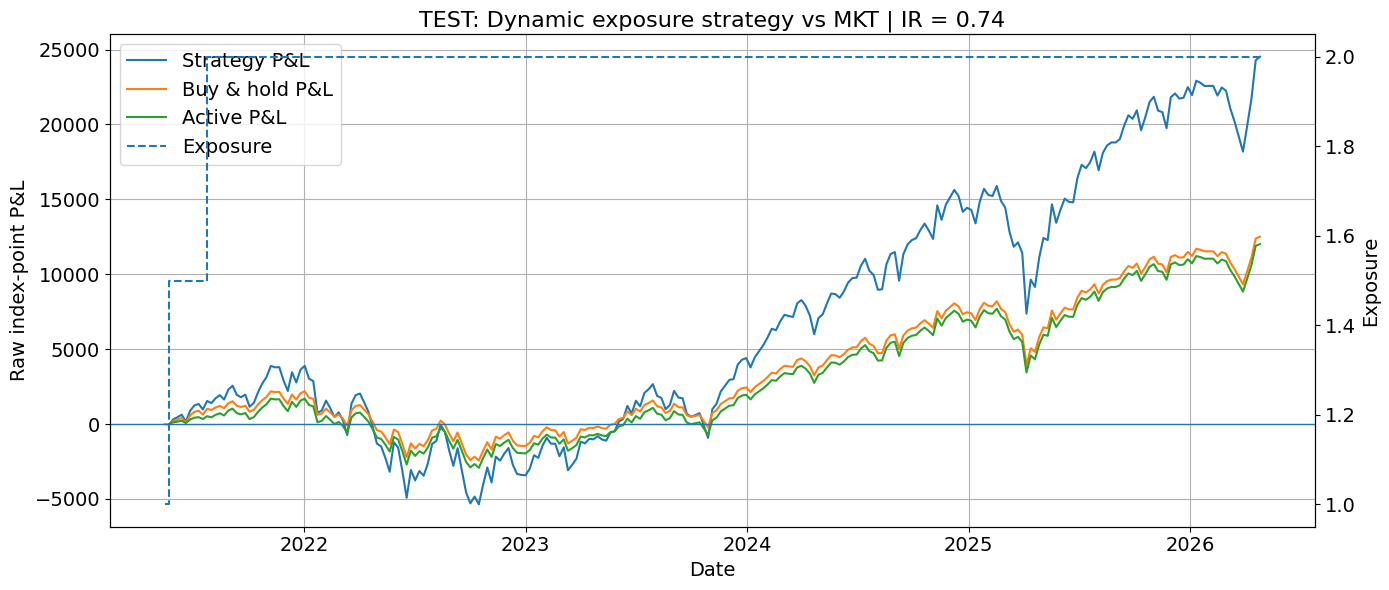

In [569]:
test_ir = IR(bt_test_ir)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_test_ir.index, bt_test_ir["strategy_pnl"], label="Strategy P&L")
ax1.plot(bt_test_ir.index, bt_test_ir["buy_hold_pnl"], label="Buy & hold P&L")
ax1.plot(bt_test_ir.index, bt_test_ir["active_pnl"], label="Active P&L")

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw index-point P&L", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_test_ir.index, bt_test_ir["w"], where="post", label="Exposure", linestyle="--")
ax2.set_ylabel("Exposure", fontsize=14)
ax2.tick_params(axis="both", labelsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()

ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title(f"TEST: Dynamic exposure strategy vs MKT | IR = {test_ir:.2f}", fontsize=16)
plt.tight_layout()
plt.show()

In [571]:
pd.Series({
    "n_test_obs": len(bt_test_ir),
    "mean_active_ret": bt_test_ir["active_ret"].mean(),
    "std_active_ret": bt_test_ir["active_ret"].std(),
    "IR": IR(bt_test_ir),
    "final_active_pnl": bt_test_ir["active_pnl"].iloc[-1],
    "avg_exposure": bt_test_ir["w"].mean(),
    "min_exposure": bt_test_ir["w"].min(),
    "max_exposure": bt_test_ir["w"].max(),
})

n_test_obs            259.000000
mean_active_ret         0.002364
std_active_ret          0.022914
IR                      0.744079
final_active_pnl    12014.450000
avg_exposure            1.978764
min_exposure            1.000000
max_exposure            2.000000
dtype: float64

In [572]:
bt_test_ir[["active_ret", "active_pnl"]].tail()

,active_ret,active_pnl
Date,,
2026-03-29,-0.019519,8845.92
2026-04-05,0.033930,9713.79
2026-04-12,0.034070,10614.81
2026-04-19,0.046805,11894.79
2026-04-26,0.004180,12014.45


In [573]:
def add_constant_exposure_benchmark(bt):
    bt = bt.copy()

    w_bar = bt["w"].mean()

    bt["mkt_ret"] = bt["S"].pct_change()
    bt["strategy_ret"] = bt["w"].shift(1) * bt["mkt_ret"]
    bt["const_w_ret"] = w_bar * bt["mkt_ret"]

    bt["active_ret_vs_MKT"] = bt["strategy_ret"] - bt["mkt_ret"]
    bt["active_ret_vs_const_w"] = bt["strategy_ret"] - bt["const_w_ret"]

    bt = bt.replace([np.inf, -np.inf], np.nan)

    return bt

In [574]:
def IR_series(x, periods_per_year=52):
    x = pd.Series(x).dropna()
    vol = x.std(ddof=1)
    if vol == 0:
        return np.nan
    return x.mean() / vol * np.sqrt(periods_per_year)

In [575]:
bt_test_check = add_constant_exposure_benchmark(bt_test)

pd.Series({
    "IR_vs_MKT_1x": IR_series(bt_test_check["active_ret_vs_MKT"]),
    "IR_vs_const_avg_exposure": IR_series(bt_test_check["active_ret_vs_const_w"]),
    "avg_exposure": bt_test_check["w"].mean(),
})

IR_vs_MKT_1x               -0.003034
IR_vs_const_avg_exposure   -0.388002
avg_exposure                1.388031
dtype: float64

In [576]:
def IR_series(x, periods_per_year=52):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    vol = x.std(ddof=1)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return x.mean() / vol * np.sqrt(periods_per_year)


def add_constant_exposure_benchmark(bt):
    bt = bt.copy()

    w_bar = bt["w"].mean()

    bt["mkt_ret"] = bt["S"].pct_change()
    bt["strategy_ret"] = bt["w"].shift(1) * bt["mkt_ret"]
    bt["const_w_ret"] = w_bar * bt["mkt_ret"]

    bt["active_ret_vs_MKT"] = bt["strategy_ret"] - bt["mkt_ret"]
    bt["active_ret_vs_const_w"] = bt["strategy_ret"] - bt["const_w_ret"]

    return bt.replace([np.inf, -np.inf], np.nan)


def extract_test_pred(run):
    if isinstance(run, dict):
        for k in ["test_pred", "pred", "pred_test", "y_pred_test"]:
            if k in run:
                return np.asarray(run[k]).ravel()

        if "diag" in run:
            diag = run["diag"]
            for k in ["test_pred", "pred", "pred_test", "y_pred_test"]:
                if k in diag:
                    return np.asarray(diag[k]).ravel()

    return np.asarray(run).ravel()


raw_mkt_test = df.loc[X_test.index, "_MKT"]

seed_compare = []

if isinstance(seed_runs, dict):
    run_iter = list(seed_runs.items())
else:
    run_iter = list(enumerate(seed_runs))

for seed_key, run in run_iter:
    pred = extract_test_pred(run)

    if len(pred) != len(raw_mkt_test):
        pred = pred[-len(raw_mkt_test):]

    bt_seed = backtest_dynamic_exposure_self_financing(
        pred=pred,
        raw_mkt=raw_mkt_test,
        threshold=1,
        step=0.1,
        base=1.0,
        min_w=0,
        max_w=2
    )

    bt_seed = add_constant_exposure_benchmark(bt_seed)

    seed_compare.append({
        "seed_key": seed_key,
        "test_IR_vs_MKT_1x": IR_series(bt_seed["active_ret_vs_MKT"]),
        "test_IR_vs_const_avg_exposure": IR_series(bt_seed["active_ret_vs_const_w"]),
        "avg_exposure": bt_seed["w"].mean(),
        "min_exposure": bt_seed["w"].min(),
        "max_exposure": bt_seed["w"].max(),
        "final_active_pnl_vs_MKT": bt_seed["active_pnl"].iloc[-1],
    })

seed_compare = pd.DataFrame(seed_compare)

seed_summary_fixed = seed_summary.copy().reset_index(drop=False)

if len(seed_summary_fixed) == len(seed_compare):
    seed_results = pd.concat(
        [
            seed_summary_fixed.reset_index(drop=True),
            seed_compare.reset_index(drop=True)
        ],
        axis=1
    )
else:
    seed_results = seed_compare.copy()

display(seed_results)

cols = [
    "test_loss",
    "test_hit",
    "test_IR",
    "test_IR_vs_MKT_1x",
    "test_IR_vs_const_avg_exposure",
    "avg_exposure",
    "min_exposure",
    "max_exposure",
    "final_active_pnl_vs_MKT",
]

cols = [c for c in cols if c in seed_results.columns]

display(seed_results[cols].describe())

C:\Users\trist\AppData\Local\Temp\ipykernel_31620\2153938373.py:28: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  bt["dw"].iloc[0] = bt["w"].iloc[0] - base
C:\Users\trist\AppData\Local\Temp\ipykernel_31620\2153938373.py:28: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves

,seed,train_mse,test_mse,train_hit,test_hit,test_corr,seed_key,test_IR_vs_MKT_1x,test_IR_vs_const_avg_exposure,avg_exposure,min_exposure,max_exposure,final_active_pnl_vs_MKT
0,8663,0.366669,0.248198,0.807536,0.873077,0.910573,8663,-0.465472,-0.861194,1.085328,5.000000e-01,1.5,-2417.868
1,3442,0.386730,0.298776,0.813913,0.811538,0.890952,3442,-0.774390,-0.264141,0.169498,0.000000e+00,1.0,-11414.034
2,7974,0.329104,0.265520,0.824928,0.834615,0.880541,7974,-1.276558,-0.770918,0.555598,0.000000e+00,1.3,-11291.791
3,2342,0.366763,0.145312,0.829565,0.938462,0.948574,2342,0.645285,-0.049458,1.457529,8.000000e-01,1.9,5811.096
4,1694,0.362404,0.290017,0.819130,0.853846,0.902706,1694,-1.134271,-0.707779,0.325097,0.000000e+00,1.0,-13110.566
5,4498,0.393502,0.335365,0.808696,0.811538,0.908672,4498,-1.172586,-0.813375,0.254826,0.000000e+00,1.0,-14289.413
6,2045,0.336101,0.213540,0.835362,0.853846,0.922430,2045,-0.105541,-0.436084,1.132046,1.387779e-16,1.6,-1638.604
7,1419,0.391486,0.284430,0.816232,0.823077,0.911450,1419,-1.065839,-0.559062,0.374903,0.000000e+00,1.2,-12179.275
8,7884,0.379021,0.096119,0.817391,0.946154,0.960481,7884,0.606367,-0.391673,1.737066,1.000000e+00,2.0,7950.206
9,9499,0.351912,0.178963,0.822029,0.896154,0.926433,9499,-0.916633,-0.458085,0.772587,3.000000e-01,1.1,-4533.235


,test_hit,test_IR_vs_MKT_1x,test_IR_vs_const_avg_exposure,avg_exposure,min_exposure,max_exposure,final_active_pnl_vs_MKT
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.852462,-0.589606,-0.493549,0.703838,0.222000,1.270000,-6196.746020
std,0.055343,0.702424,0.369302,0.477709,0.360436,0.367146,7378.928903
min,0.761538,-1.276558,-0.985235,0.056757,0.000000,1.000000,-14993.015000
25%,0.811538,-1.123717,-0.768029,0.288707,0.000000,1.000000,-12176.444500
50%,0.850000,-0.925838,-0.563197,0.599421,0.000000,1.050000,-8483.664000
75%,0.895192,-0.020045,-0.303348,1.061680,0.300000,1.500000,-1421.399500
max,0.961538,0.901829,0.388186,1.737066,1.000000,2.000000,9854.647000


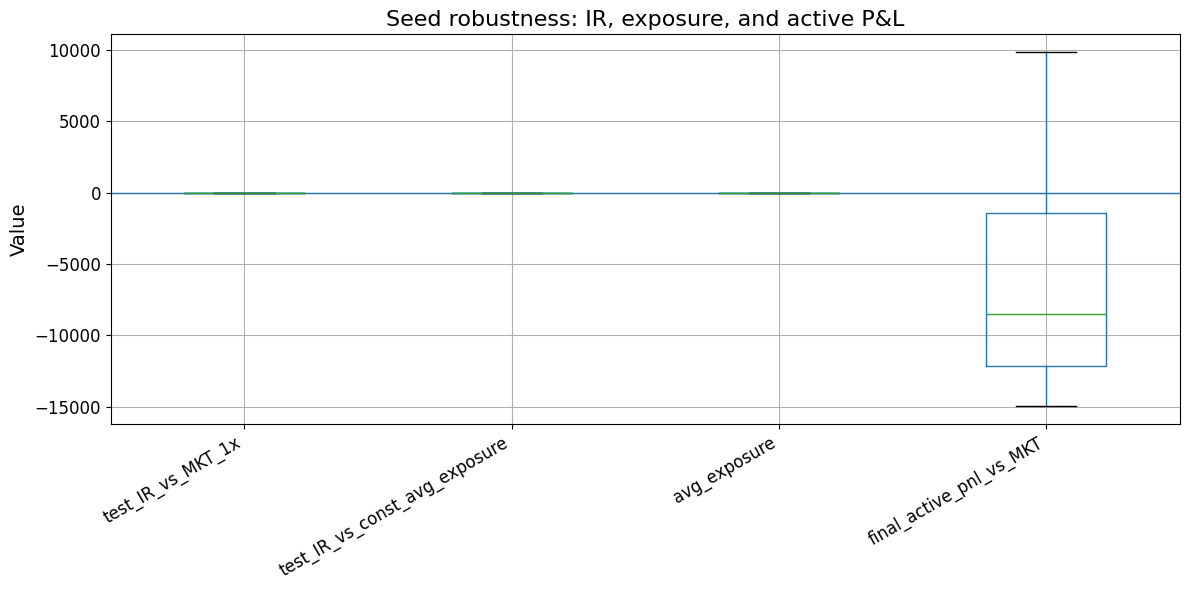

In [547]:
plot_cols = [
    "test_IR_vs_MKT_1x",
    "test_IR_vs_const_avg_exposure",
    "avg_exposure",
    "final_active_pnl_vs_MKT",
]

plot_cols = [c for c in plot_cols if c in seed_results.columns]

plt.figure(figsize=(12, 6))
seed_results[plot_cols].boxplot()
plt.axhline(0, linewidth=1)
plt.ylabel("Value", fontsize=14)
plt.title("Seed robustness: IR, exposure, and active P&L", fontsize=16)
plt.xticks(rotation=30, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()